In [12]:
# Install PySpark in Colab
!pip install pyspark
!pip install findspark

import findspark
findspark.init()

Phase 1: Setup Environment setup and data loading

In [13]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Create Spark session
spark = SparkSession.builder \
    .appName("VideoGameSalesAnalysis") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")
print(f"Spark context: {spark.sparkContext.appName}")


# Load dataset (adjust path as needed)
df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("nullValue", "NA") \
    .csv("Video_Games.csv")

print(f"Dataset loaded: {df.count()} rows, {len(df.columns)} columns")
df.printSchema()


Spark version: 4.0.2
Spark context: VideoGameSalesAnalysis
Dataset loaded: 16928 rows, 17 columns
root
 |-- index: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Platform: string (nullable = true)
 |-- Year_of_Release: double (nullable = true)
 |-- Genre: string (nullable = true)
 |-- Publisher: string (nullable = true)
 |-- NA_Sales: double (nullable = true)
 |-- EU_Sales: double (nullable = true)
 |-- JP_Sales: double (nullable = true)
 |-- Other_Sales: double (nullable = true)
 |-- Global_Sales: double (nullable = true)
 |-- Critic_Score: double (nullable = true)
 |-- Critic_Count: double (nullable = true)
 |-- User_Score: string (nullable = true)
 |-- User_Count: double (nullable = true)
 |-- Developer: string (nullable = true)
 |-- Rating: string (nullable = true)



Phase 2: Data Cleaning and Missing Value Imputation

In [14]:

from pyspark.sql import functions as F

# Missing value analysis
def missing_value_analysis(df):
    total_rows = df.count()
    missing_data = []
    for col_name in df.columns:
        null_count = df.filter(F.col(col_name).isNull()).count()
        missing_pct = (null_count / total_rows) * 100
        missing_data.append((col_name, null_count, missing_pct))
    missing_df = spark.createDataFrame(missing_data, ["Column", "Null_Count", "Missing_Percentage"])
    missing_df = missing_df.orderBy(F.col("Missing_Percentage").desc())
    print(f"\nTotal rows: {total_rows}")
    print("=== MISSING VALUE ANALYSIS ===")
    missing_df.show(truncate=False)
    return missing_df

missing_summary = missing_value_analysis(df)

# Fix User_Score (convert 'tbd' to null, then cast)
df = df.withColumn("User_Score",
    F.when(F.col("User_Score") == "tbd", None)
    .otherwise(F.col("User_Score").cast("float")))

# Cast columns to appropriate types
df = df.withColumn("Year_of_Release", F.col("Year_of_Release").cast("integer")) \
       .withColumn("Critic_Score", F.col("Critic_Score").cast("float")) \
       .withColumn("Critic_Count", F.col("Critic_Count").cast("integer")) \
       .withColumn("User_Count", F.col("User_Count").cast("integer")) \
       .withColumn("NA_Sales", F.col("NA_Sales").cast("float")) \
       .withColumn("EU_Sales", F.col("EU_Sales").cast("float")) \
       .withColumn("JP_Sales", F.col("JP_Sales").cast("float")) \
       .withColumn("Other_Sales", F.col("Other_Sales").cast("float")) \
       .withColumn("Global_Sales", F.col("Global_Sales").cast("float"))

# Filter valid years
df = df.filter((F.col("Year_of_Release") >= 1980) & (F.col("Year_of_Release") <= 2020))
print(f"After year filter: {df.count()} rows")

# Fill null Genre and Rating
df = df.fillna({"Genre": "Unknown", "Rating": "RP"})

# Impute critic/user scores using Genre medians (single join!)
medians_df = df.groupBy("Genre").agg(
    F.expr("percentile_approx(Critic_Score, 0.5)").alias("med_critic_score"),
    F.expr("percentile_approx(Critic_Count, 0.5)").alias("med_critic_count"),
    F.expr("percentile_approx(User_Score, 0.5)").alias("med_user_score"),
    F.expr("percentile_approx(User_Count, 0.5)").alias("med_user_count")
)

df = df.join(medians_df, on="Genre", how="left")

df = df.withColumn("Critic_Score", F.coalesce(F.col("Critic_Score"), F.col("med_critic_score"))) \
       .withColumn("Critic_Count", F.coalesce(F.col("Critic_Count"), F.col("med_critic_count"))) \
       .withColumn("User_Score",   F.coalesce(F.col("User_Score"),   F.col("med_user_score"))) \
       .withColumn("User_Count",   F.coalesce(F.col("User_Count"),   F.col("med_user_count")))

df = df.drop("med_critic_score", "med_critic_count", "med_user_score", "med_user_count")

# Verify
print("=== NULLS AFTER IMPUTATION ===")
for c in ["Critic_Score", "Critic_Count", "User_Score", "User_Count", "Rating"]:
    print(f"{c}: {df.filter(F.col(c).isNull()).count()} nulls")
print(f"Final clean rows: {df.count()}")



Total rows: 16928
=== MISSING VALUE ANALYSIS ===
+---------------+----------+--------------------+
|Column         |Null_Count|Missing_Percentage  |
+---------------+----------+--------------------+
|User_Count     |9210      |54.406899810964084  |
|Critic_Score   |8668      |51.20510396975425   |
|Critic_Count   |8668      |51.20510396975425   |
|Rating         |6836      |40.382797731569     |
|User_Score     |6769      |39.98700378071834   |
|Developer      |6688      |39.50850661625709   |
|Year_of_Release|273       |1.6127126654064274  |
|Publisher      |55        |0.32490548204158787 |
|Name           |2         |0.011814744801512287|
|Genre          |2         |0.011814744801512287|
|JP_Sales       |0         |0.0                 |
|index          |0         |0.0                 |
|Other_Sales    |0         |0.0                 |
|Platform       |0         |0.0                 |
|Global_Sales   |0         |0.0                 |
|NA_Sales       |0         |0.0                 |


Phase 3: Exploratory Data Analysis (EDA)

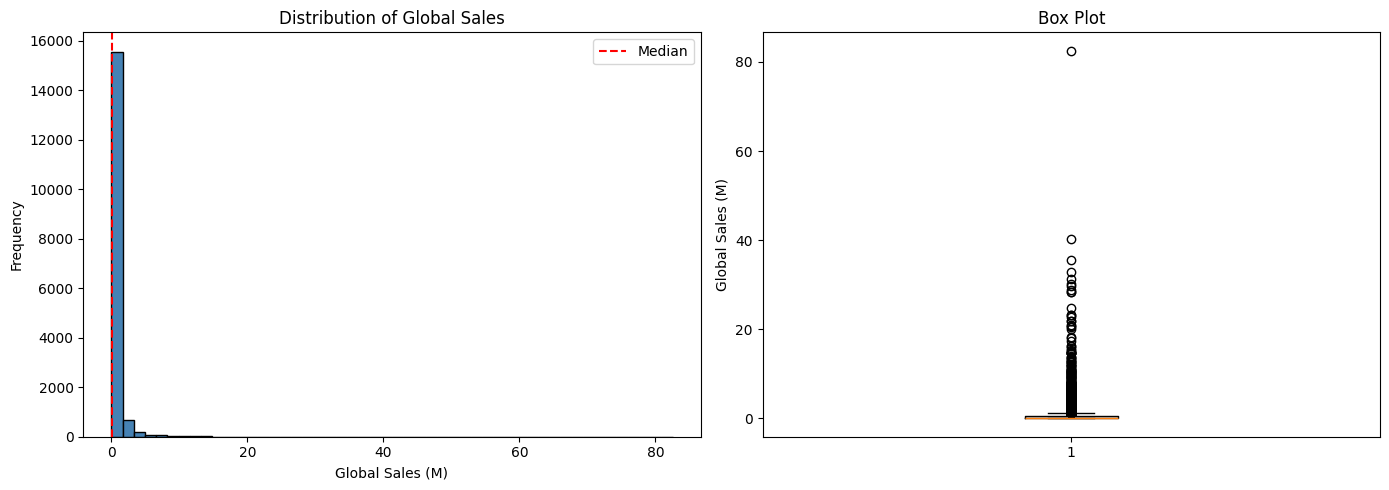

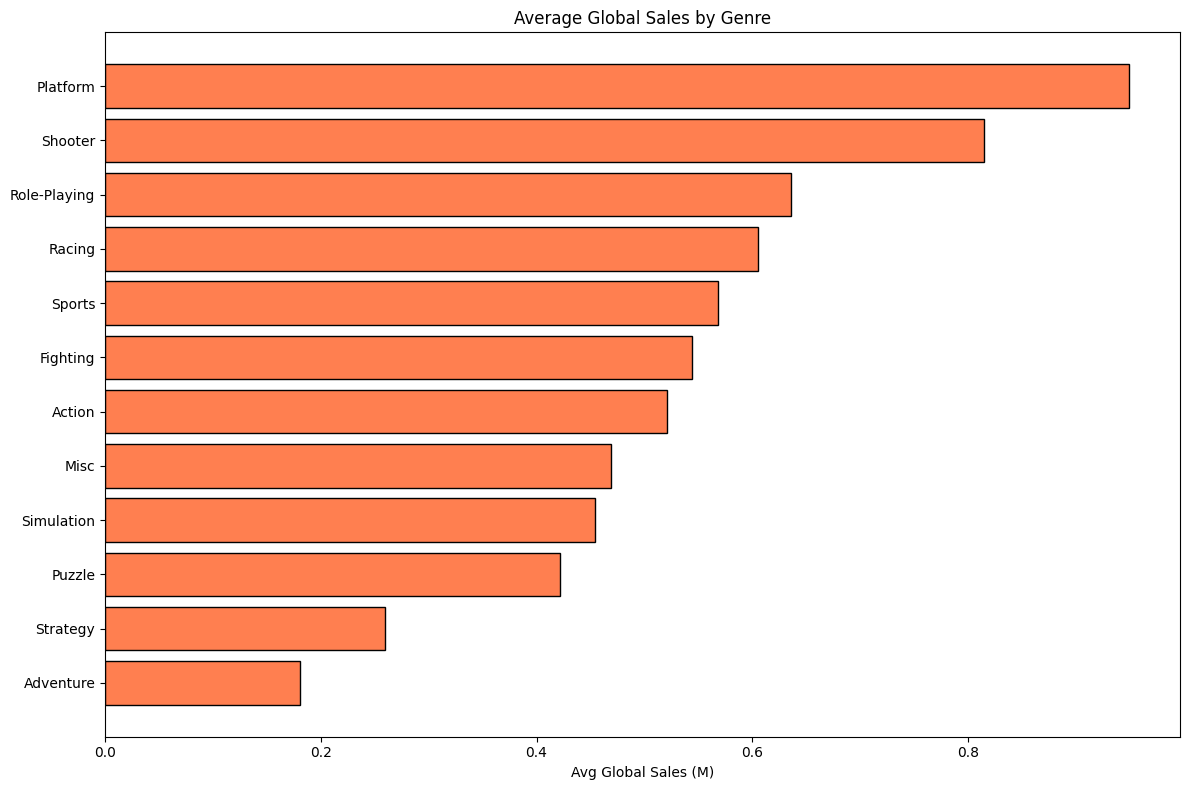

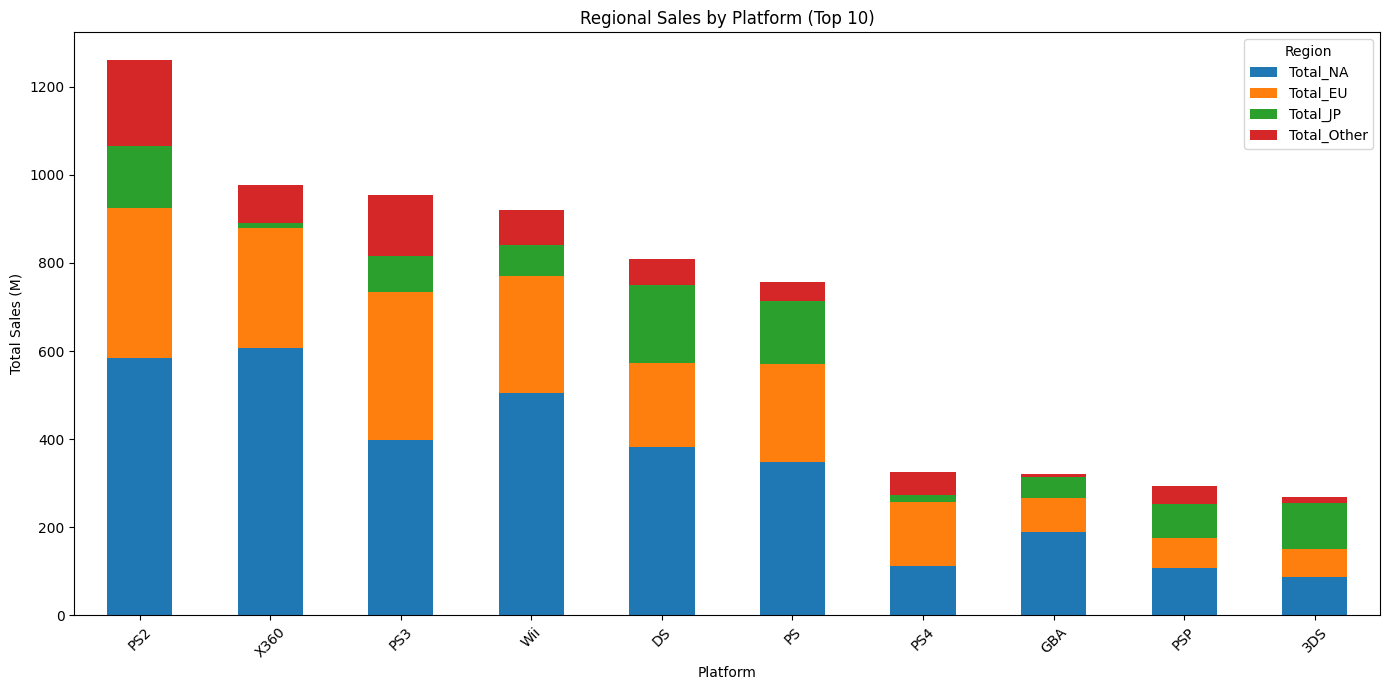

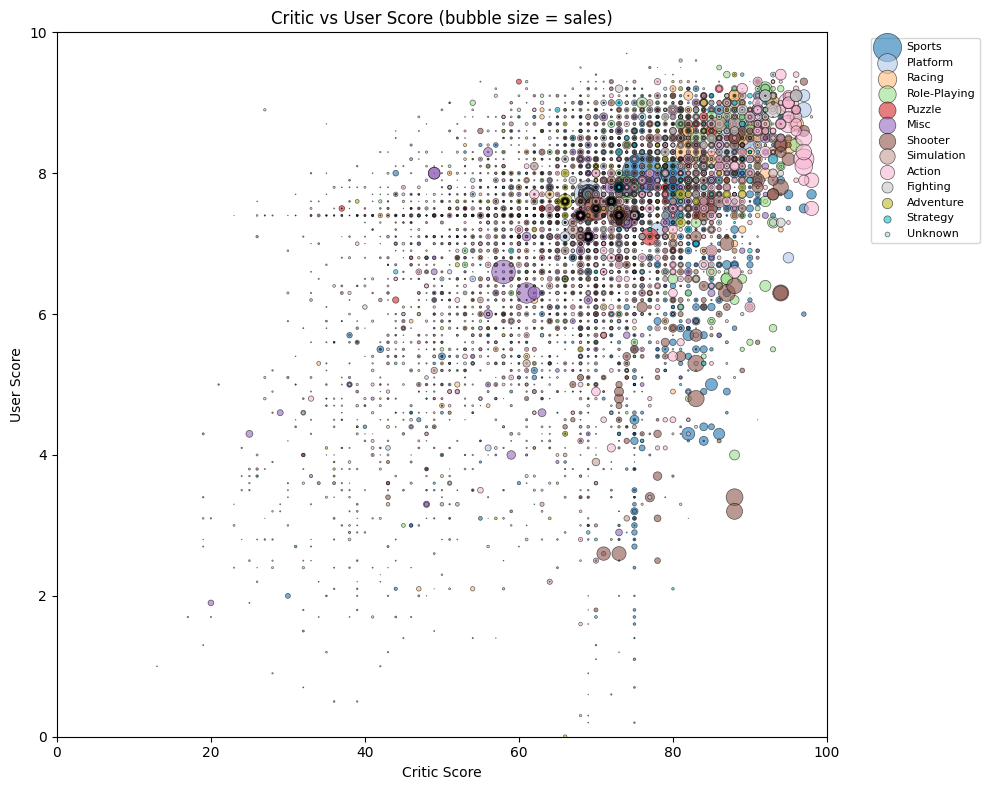

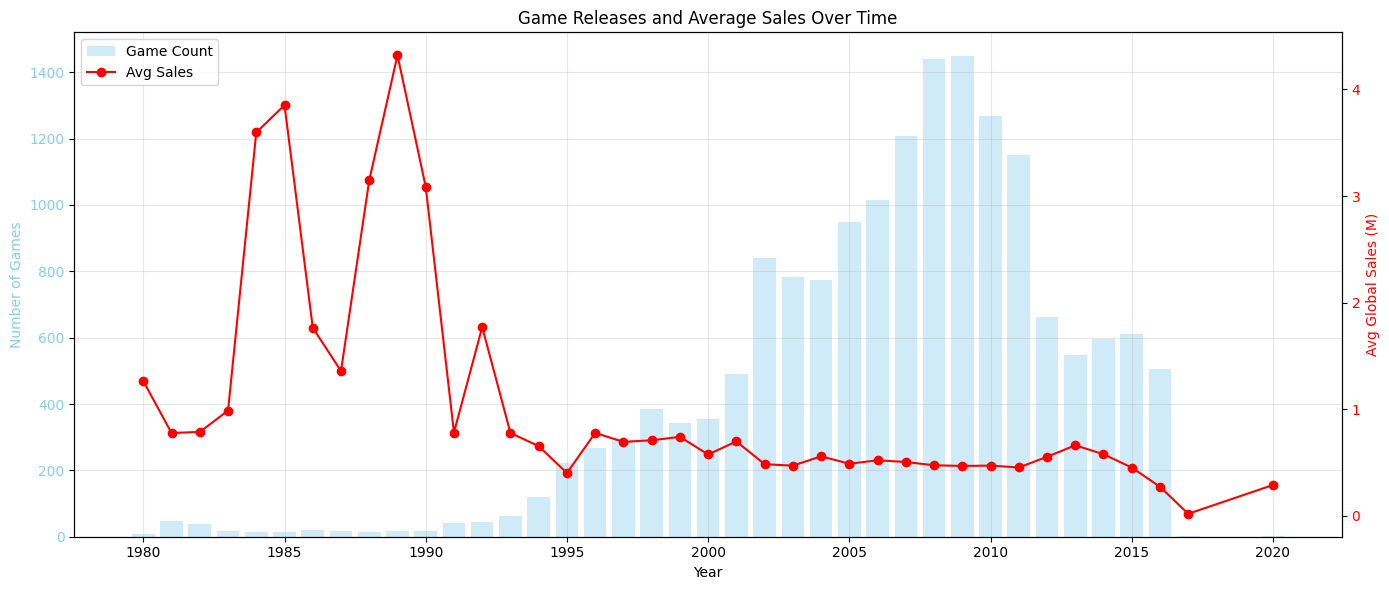

In [15]:
# Convert sample to pandas for plotting
sample_df = df.select("Global_Sales", "Genre", "Platform", "NA_Sales", "EU_Sales", "JP_Sales").toPandas()

# Global Sales Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(sample_df['Global_Sales'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Global Sales (M)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Global Sales')
axes[0].axvline(sample_df['Global_Sales'].median(), color='red', linestyle='--', label='Median')
axes[0].legend()
axes[1].boxplot(sample_df['Global_Sales'], vert=True)
axes[1].set_ylabel('Global Sales (M)'); axes[1].set_title('Box Plot')
plt.tight_layout(); plt.savefig('global_sales_dist.png', dpi=300); plt.show()

# Sales by Genre (cleaned)
genre_sales = df.filter(F.col("Genre") != "Unknown").groupBy("Genre") \
    .agg(F.round(F.avg("Global_Sales"), 4).alias("Avg_Global_Sales"),
         F.round(F.sum("Global_Sales"), 2).alias("Total_Global_Sales"),
         F.count("*").alias("Game_Count")) \
    .orderBy(F.col("Avg_Global_Sales").desc())
genre_df = genre_sales.toPandas().sort_values("Avg_Global_Sales", ascending=True)

fig, ax = plt.subplots(figsize=(12,8))
ax.barh(genre_df['Genre'], genre_df['Avg_Global_Sales'], color='coral', edgecolor='black')
ax.set_xlabel('Avg Global Sales (M)'); ax.set_title('Average Global Sales by Genre')
plt.tight_layout(); plt.savefig('sales_by_genre.png', dpi=300); plt.show()

# Regional Sales by Platform (top 10)
platform_regional = df.groupBy("Platform").agg(
    F.sum("NA_Sales").alias("Total_NA"), F.sum("EU_Sales").alias("Total_EU"),
    F.sum("JP_Sales").alias("Total_JP"), F.sum("Other_Sales").alias("Total_Other"),
    F.sum("Global_Sales").alias("Total_Global")
).orderBy(F.col("Total_Global").desc()).limit(10).toPandas()

platform_regional.set_index('Platform')[['Total_NA','Total_EU','Total_JP','Total_Other']].plot(
    kind='bar', stacked=True, figsize=(14,7), color=['#1f77b4','#ff7f0e','#2ca02c','#d62728'])
plt.title('Regional Sales by Platform (Top 10)'); plt.ylabel('Total Sales (M)')
plt.xticks(rotation=45); plt.legend(title='Region'); plt.tight_layout()
plt.savefig('regional_sales_platform.png', dpi=300); plt.show()

# Critic vs User Score scatter
score_df = df.select("Critic_Score", "User_Score", "Global_Sales", "Genre").toPandas()
fig, ax = plt.subplots(figsize=(10,8))
genres = score_df['Genre'].unique()
colors = plt.cm.tab20(np.linspace(0,1,len(genres)))
for genre, col in zip(genres, colors):
    subset = score_df[score_df['Genre']==genre]
    ax.scatter(subset['Critic_Score'], subset['User_Score'],
               s=subset['Global_Sales']*10, alpha=0.6, label=genre, color=col, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Critic Score'); ax.set_ylabel('User Score')
ax.set_title('Critic vs User Score (bubble size = sales)')
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)
ax.set_xlim(0,100); ax.set_ylim(0,10)
plt.tight_layout(); plt.savefig('critic_vs_user.png', dpi=300); plt.show()

# Temporal trends
yearly_sales = df.groupBy("Year_of_Release").agg(
    F.avg("Global_Sales").alias("Avg_Sales"), F.count("*").alias("Game_Count")
).orderBy("Year_of_Release").toPandas()

fig, ax1 = plt.subplots(figsize=(14,6))
ax1.bar(yearly_sales['Year_of_Release'], yearly_sales['Game_Count'], alpha=0.4, color='skyblue', label='Game Count')
ax1.set_xlabel('Year'); ax1.set_ylabel('Number of Games', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax2 = ax1.twinx()
ax2.plot(yearly_sales['Year_of_Release'], yearly_sales['Avg_Sales'], 'ro-', label='Avg Sales')
ax2.set_ylabel('Avg Global Sales (M)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
ax1.set_title('Game Releases and Average Sales Over Time'); ax1.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('temporal_trends.png', dpi=300); plt.show()

Phase 4: Feature Engineering

In [16]:
# Re-import functions to avoid shadowing
from pyspark.sql import functions as F
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
import builtins

# Derived Features
# Score divergence
df = df.withColumn("Score_Divergence", F.round(F.col("Critic_Score") - (F.col("User_Score") * 10), 2))
# Total reviews
df = df.withColumn("Total_Reviews", F.col("Critic_Count") + F.col("User_Count"))
# Log reviews
df = df.withColumn("Log_Total_Reviews", F.when(F.col("Total_Reviews") > 0, F.log1p(F.col("Total_Reviews"))).otherwise(0))
# Regional ratios
df = df.withColumn("NA_Ratio", F.when(F.col("Global_Sales") > 0, F.round(F.col("NA_Sales") / F.col("Global_Sales"), 4)).otherwise(0))
df = df.withColumn("EU_Ratio", F.when(F.col("Global_Sales") > 0, F.round(F.col("EU_Sales") / F.col("Global_Sales"), 4)).otherwise(0))
df = df.withColumn("JP_Ratio", F.when(F.col("Global_Sales") > 0, F.round(F.col("JP_Sales") / F.col("Global_Sales"), 4)).otherwise(0))
# Temporary Other_Ratio for concentration
df = df.withColumn("Other_Ratio_temp", F.when(F.col("Global_Sales") > 0, F.round(F.col("Other_Sales") / F.col("Global_Sales"), 4)).otherwise(0))
# Regional concentration (HHI)
df = df.withColumn("Regional_Concentration", F.round(
    F.col("NA_Ratio")**2 + F.col("EU_Ratio")**2 + F.col("JP_Ratio")**2 + F.col("Other_Ratio_temp")**2, 4))
df = df.drop("Other_Ratio_temp")
# Platform age
platform_years = {'2600':1977, '3DS':2011, 'DC':1998, 'DS':2004, 'GB':1989, 'GBA':2001, 'GC':2001, 'GEN':1988, 'N64':1996, 'NES':1983, 'PC':1981, 'PS':1994, 'PS2':2000, 'PS3':2006, 'PS4':2013, 'PSP':2004, 'PSV':2011, 'SAT':1994, 'SCD':1991, 'SNES':1990, 'TG16':1987, 'Wii':2006, 'WiiU':2012, 'X360':2005, 'XB':2001, 'XOne':2013}
map_items = []
for k, v in platform_years.items(): map_items.extend([F.lit(k), F.lit(v)])
platform_map = F.create_map(*map_items)
df = df.withColumn("_plat_year", platform_map[F.col("Platform")])
df = df.withColumn("Platform_Age", F.when(F.col("_plat_year").isNotNull(), F.col("Year_of_Release") - F.col("_plat_year")).otherwise(-1))
df = df.drop("_plat_year")
# Has reviews flag
df = df.withColumn("Has_Reviews", F.when((F.col("Critic_Count") > 0) | (F.col("User_Count") > 0), 1).otherwise(0))
# Sales per review
df = df.withColumn("Sales_Per_Review", F.when(F.col("Total_Reviews") > 0, F.round(F.col("Global_Sales") / F.col("Total_Reviews"), 6)).otherwise(0))
# Publisher stats (single join with distinct names)
pub_stats = df.groupBy("Publisher").agg(F.avg("Global_Sales").alias("pub_avg_sales"), F.count("*").alias("pub_game_count"))
df = df.join(pub_stats, on="Publisher", how="left")
total_games = df.count()
df = df.withColumn("pub_freq_norm", F.round(F.col("pub_game_count") / total_games, 6))
df = df.withColumn("is_top_publisher", F.when(F.col("pub_freq_norm") > 0.01, 1).otherwise(0))
# Developer game count
dev_stats = df.groupBy("Developer").agg(F.count("*").alias("dev_game_count"))
df = df.join(dev_stats, on="Developer", how="left")

# Handle duplicate columns (should be none, but to be safe)
from collections import Counter
col_counts = Counter(df.columns)
duplicates = {k:v for k,v in col_counts.items() if v>1}
if duplicates:
    print(f"Duplicate columns found: {duplicates}. Removing...")
    seen = set()
    unique_cols = [c for c in df.columns if c not in seen and not seen.add(c)]
    df = df.select(*unique_cols)
print(f"Columns after feature engineering: {len(df.columns)}")

#  Define features for modeling
numerical_features = [
    "Year_of_Release", "Critic_Score", "User_Score",
    "Score_Divergence", "Log_Total_Reviews",
    "NA_Ratio", "EU_Ratio", "JP_Ratio",
    "Regional_Concentration", "Platform_Age", "Has_Reviews",
    "Sales_Per_Review", "pub_avg_sales", "pub_freq_norm", "is_top_publisher"
]
categorical_features = ["Platform", "Genre", "Rating"]

# Verify existence
for f in numerical_features + categorical_features:
    if f not in df.columns: print(f"WARNING: {f} not in df!")

# Prepare data for modeling
df_model = df.filter((F.col("Global_Sales") > 0) & (F.col("Global_Sales").isNotNull()))
df_model = df_model.dropna(subset=numerical_features + categorical_features)
print(f"Modeling rows: {df_model.count()}")

train_data, test_data = df_model.randomSplit([0.8, 0.2], seed=42)

# Build pipeline
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in categorical_features]
encoders = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_vec", dropLast=True) for c in categorical_features]
encoded_cols = [c+"_vec" for c in categorical_features]
assembler = VectorAssembler(inputCols=numerical_features+encoded_cols, outputCol="features", handleInvalid="skip")
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
pipeline = Pipeline(stages=indexers+encoders+[assembler, scaler])

pipeline_model = pipeline.fit(train_data)
train_transformed = pipeline_model.transform(train_data).cache()
test_transformed = pipeline_model.transform(test_data).cache()

vec_size = len(train_transformed.select("scaled_features").first()[0])
print(f"Feature vector size: {vec_size}")

Columns after feature engineering: 32
Modeling rows: 16620
Feature vector size: 66


Phase 5: Model Building (Regression)

LR -> Train RMSE: 1.1153, Test RMSE: 0.8736, Test R2: 0.5614
RF -> Train RMSE: 0.9046, Test RMSE: 0.7089, Test R2: 0.7112
GBT -> Train RMSE: 0.1965, Test RMSE: 0.7772, Test R2: 0.6529
                 Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
     Linear Regression    1.115293   0.873623   0.325962  0.316808  0.523765 0.561427
         Random Forest    0.904563   0.708888   0.234377  0.253809  0.686728 0.711232
Gradient-Boosted Trees    0.196532   0.777228   0.063260  0.158903  0.985212 0.652871

Best model: Random Forest (Test RMSE=0.7089, R²=0.7112)


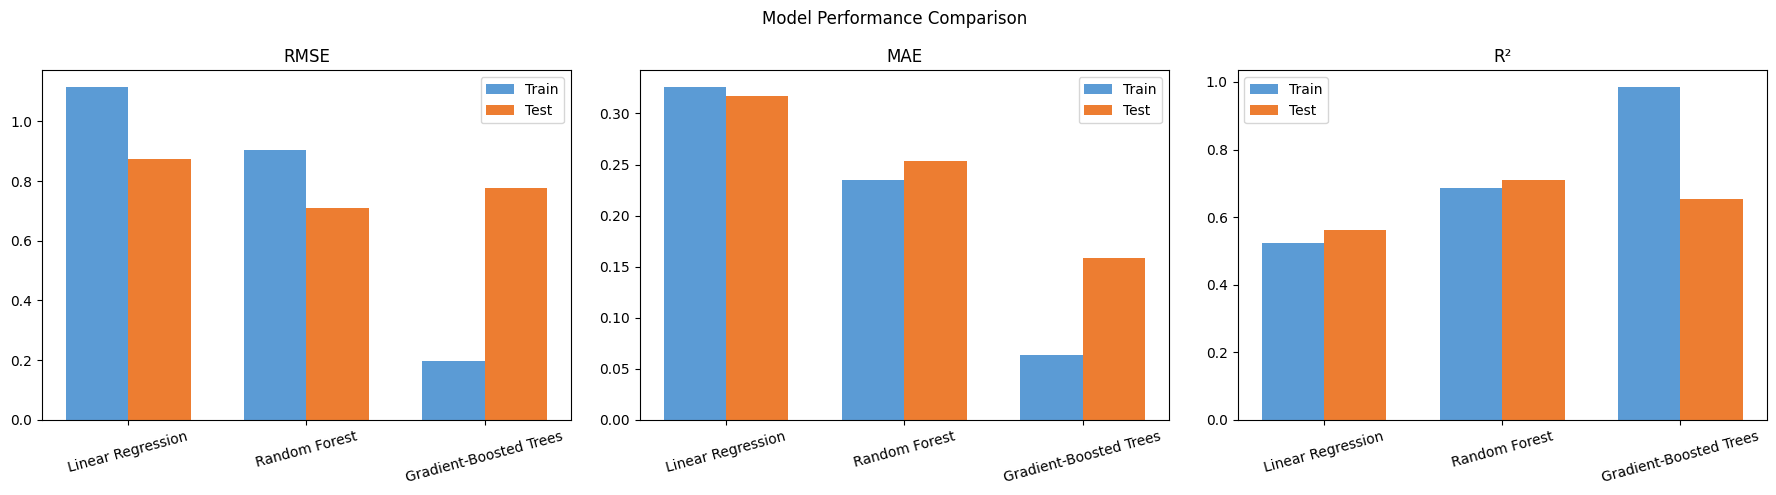

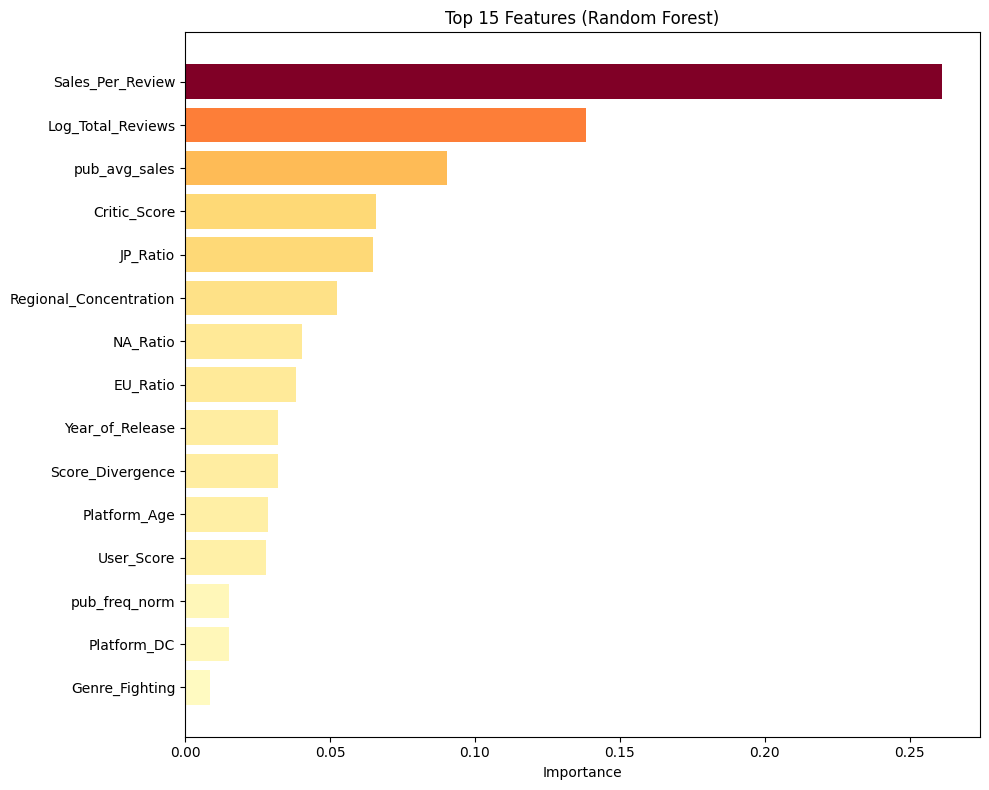

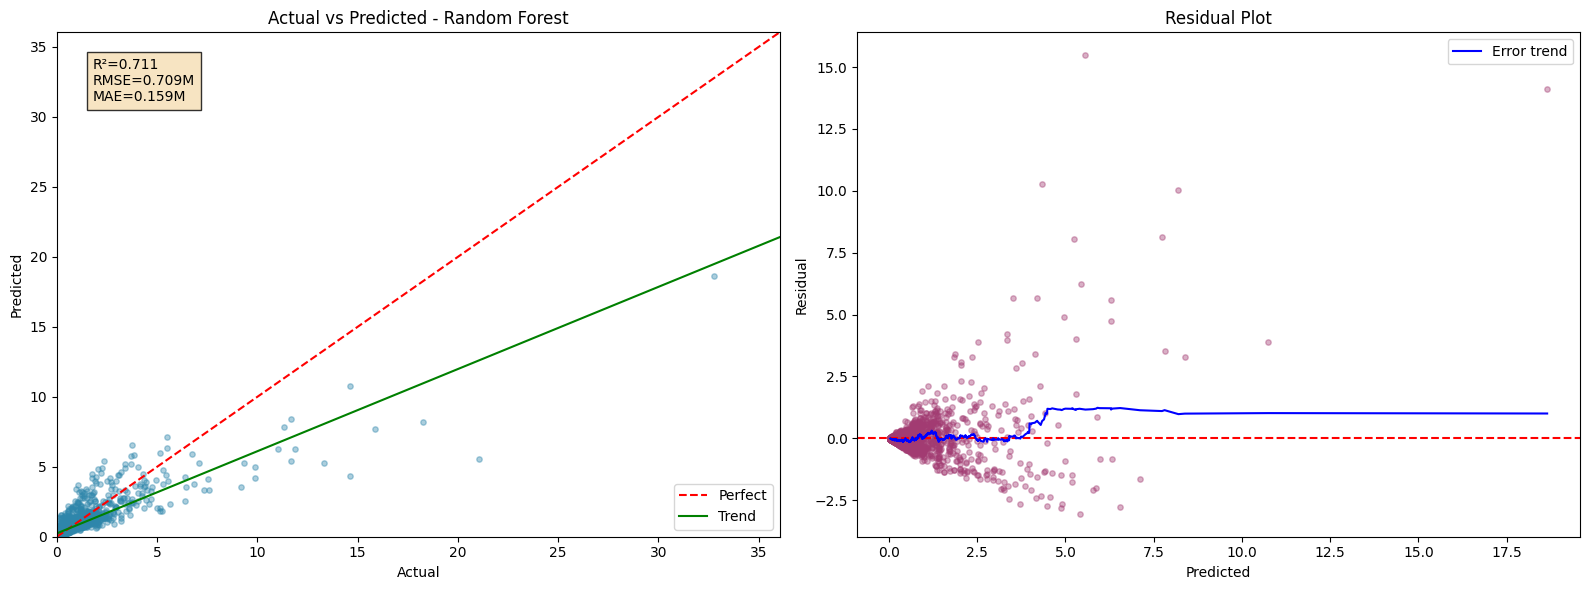

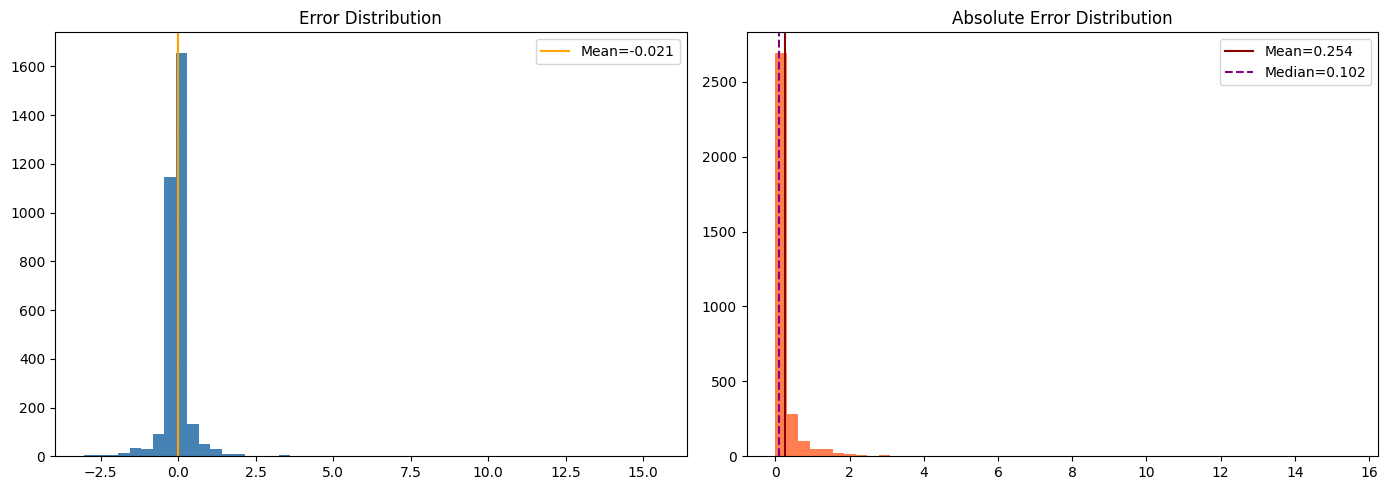

Model saved.
Predictions exported.


In [17]:
import builtins
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

def evaluate(preds, pred_col):
    rmse = RegressionEvaluator(labelCol="Global_Sales", predictionCol=pred_col, metricName="rmse").evaluate(preds)
    mae  = RegressionEvaluator(labelCol="Global_Sales", predictionCol=pred_col, metricName="mae").evaluate(preds)
    r2   = RegressionEvaluator(labelCol="Global_Sales", predictionCol=pred_col, metricName="r2").evaluate(preds)
    return rmse, mae, r2

# Linear Regression
lr = LinearRegression(featuresCol="scaled_features", labelCol="Global_Sales", predictionCol="lr_pred", maxIter=100, regParam=0.1, elasticNetParam=0.5)
lr_model = lr.fit(train_transformed)
lr_train_rmse, lr_train_mae, lr_train_r2 = evaluate(lr_model.transform(train_transformed), "lr_pred")
lr_test_rmse, lr_test_mae, lr_test_r2 = evaluate(lr_model.transform(test_transformed), "lr_pred")
print(f"LR -> Train RMSE: {lr_train_rmse:.4f}, Test RMSE: {lr_test_rmse:.4f}, Test R2: {lr_test_r2:.4f}")

# Random Forest
rf = RandomForestRegressor(featuresCol="scaled_features", labelCol="Global_Sales", predictionCol="rf_pred", numTrees=100, maxDepth=10, minInstancesPerNode=5, seed=42, featureSubsetStrategy="sqrt")
rf_model = rf.fit(train_transformed)
rf_train_rmse, rf_train_mae, rf_train_r2 = evaluate(rf_model.transform(train_transformed), "rf_pred")
rf_test_rmse, rf_test_mae, rf_test_r2 = evaluate(rf_model.transform(test_transformed), "rf_pred")
print(f"RF -> Train RMSE: {rf_train_rmse:.4f}, Test RMSE: {rf_test_rmse:.4f}, Test R2: {rf_test_r2:.4f}")
rf_importance = rf_model.featureImportances.toArray()

# Gradient-Boosted Trees
gbt = GBTRegressor(featuresCol="scaled_features", labelCol="Global_Sales", predictionCol="gbt_pred", maxIter=50, maxDepth=8, minInstancesPerNode=5, stepSize=0.1, seed=42)
gbt_model = gbt.fit(train_transformed)
gbt_train_rmse, gbt_train_mae, gbt_train_r2 = evaluate(gbt_model.transform(train_transformed), "gbt_pred")
gbt_test_rmse, gbt_test_mae, gbt_test_r2 = evaluate(gbt_model.transform(test_transformed), "gbt_pred")
print(f"GBT -> Train RMSE: {gbt_train_rmse:.4f}, Test RMSE: {gbt_test_rmse:.4f}, Test R2: {gbt_test_r2:.4f}")
gbt_importance = gbt_model.featureImportances.toArray()

# Model comparison
results = pd.DataFrame([
    ["Linear Regression", lr_train_rmse, lr_test_rmse, lr_train_mae, lr_test_mae, lr_train_r2, lr_test_r2],
    ["Random Forest",     rf_train_rmse, rf_test_rmse, rf_train_mae, rf_test_mae, rf_train_r2, rf_test_r2],
    ["Gradient-Boosted Trees", gbt_train_rmse, gbt_test_rmse, gbt_train_mae, gbt_test_mae, gbt_train_r2, gbt_test_r2]
], columns=["Model","Train RMSE","Test RMSE","Train MAE","Test MAE","Train R²","Test R²"])
print(results.to_string(index=False))

# Identify best model
best_idx = results["Test RMSE"].idxmin()
best_model_name = results.loc[best_idx, "Model"]
best_test_rmse = results.loc[best_idx, "Test RMSE"]
best_test_r2 = results.loc[best_idx, "Test R²"]
if best_model_name == "Gradient-Boosted Trees":
    best_test_preds = gbt_model.transform(test_transformed)
    best_pred_col = "gbt_pred"
    best_importance = gbt_importance
elif best_model_name == "Random Forest":
    best_test_preds = rf_model.transform(test_transformed)
    best_pred_col = "rf_pred"
    best_importance = rf_importance
else:
    best_test_preds = lr_model.transform(test_transformed)
    best_pred_col = "lr_pred"
    best_importance = None

print(f"\nBest model: {best_model_name} (Test RMSE={best_test_rmse:.4f}, R²={best_test_r2:.4f})")

# Visualizations
# Model comparison charts
fig, axes = plt.subplots(1,3,figsize=(18,5))
x = np.arange(3); w=0.35
models = results["Model"]
axes[0].bar(x-w/2, results["Train RMSE"], w, label="Train", color="#5B9BD5"); axes[0].bar(x+w/2, results["Test RMSE"], w, label="Test", color="#ED7D31")
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=15); axes[0].set_title("RMSE"); axes[0].legend()
axes[1].bar(x-w/2, results["Train MAE"], w, label="Train", color="#5B9BD5"); axes[1].bar(x+w/2, results["Test MAE"], w, label="Test", color="#ED7D31")
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=15); axes[1].set_title("MAE"); axes[1].legend()
axes[2].bar(x-w/2, results["Train R²"], w, label="Train", color="#5B9BD5"); axes[2].bar(x+w/2, results["Test R²"], w, label="Test", color="#ED7D31")
axes[2].set_xticks(x); axes[2].set_xticklabels(models, rotation=15); axes[2].set_title("R²"); axes[2].legend()
plt.suptitle("Model Performance Comparison"); plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300); plt.show()

# Feature Importance (RF)
num_names = numerical_features.copy()
cat_names = []
for cat_col in categorical_features:
    unique_vals = train_data.select(cat_col).distinct().orderBy(cat_col).collect()
    vals = [row[0] for row in unique_vals]
    for val in vals[:-1]:
        clean = str(val).replace(' ', '_') if val is not None else 'NULL'
        cat_names.append(f"{cat_col}_{clean}")
all_feat_names = num_names + cat_names
if len(all_feat_names) != len(rf_importance):
    n = builtins.min(len(all_feat_names), len(rf_importance))
    all_feat_names = all_feat_names[:n]; rf_importance = rf_importance[:n]
imp_df = pd.DataFrame({'Feature': all_feat_names, 'Importance': rf_importance}).sort_values('Importance', ascending=True)
top_n = builtins.min(15, len(imp_df))
top_imp = imp_df.tail(top_n)
fig, ax = plt.subplots(figsize=(10,8))
ax.barh(top_imp['Feature'], top_imp['Importance'], color=plt.cm.YlOrRd(top_imp['Importance']/top_imp['Importance'].max()))
ax.set_xlabel("Importance"); ax.set_title(f"Top {top_n} Features (Random Forest)")
plt.tight_layout(); plt.savefig("feature_importance.png", dpi=300); plt.show()

# Actual vs Predicted + Residuals
preds_pd = best_test_preds.select("Global_Sales", best_pred_col).toPandas()
preds_pd.columns = ['Actual', 'Predicted']
preds_pd['Error'] = preds_pd['Actual'] - preds_pd['Predicted']
preds_pd['Abs_Error'] = np.abs(preds_pd['Error'])
mean_err, med_err, std_err = preds_pd['Error'].mean(), preds_pd['Error'].median(), preds_pd['Error'].std()
mean_abs, med_abs = preds_pd['Abs_Error'].mean(), preds_pd['Abs_Error'].median()
best_mae_all = builtins.min(lr_test_mae, rf_test_mae, gbt_test_mae)

fig, axes = plt.subplots(1,2,figsize=(16,6))
max_val = builtins.max(preds_pd['Actual'].max(), preds_pd['Predicted'].max())*1.1
axes[0].scatter(preds_pd['Actual'], preds_pd['Predicted'], alpha=0.4, s=15, color='#2E86AB')
axes[0].plot([0,max_val],[0,max_val],'r--', label='Perfect')
z = np.polyfit(preds_pd['Actual'], preds_pd['Predicted'],1)
axes[0].plot([0,max_val], np.poly1d(z)([0,max_val]),'g-', label='Trend')
axes[0].set_xlim(0,max_val); axes[0].set_ylim(0,max_val)
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Actual vs Predicted - {best_model_name}")
axes[0].legend()
textstr = f'R²={best_test_r2:.3f}\nRMSE={best_test_rmse:.3f}M\nMAE={best_mae_all:.3f}M'
axes[0].text(0.05,0.95,textstr, transform=axes[0].transAxes, fontsize=10, va='top', bbox=dict(facecolor='wheat', alpha=0.8))

axes[1].scatter(preds_pd['Predicted'], preds_pd['Error'], alpha=0.4, s=15, color='#A23B72')
axes[1].axhline(0, color='red', linestyle='--')
sorted_idx = np.argsort(preds_pd['Predicted'])
sorted_pred = preds_pd['Predicted'].values[sorted_idx]; sorted_err = preds_pd['Error'].values[sorted_idx]
window = builtins.max(len(sorted_pred)//50, 5)
if len(sorted_pred)>=window:
    smoothed = np.convolve(sorted_err, np.ones(window)/window, mode='same')
    axes[1].plot(sorted_pred, smoothed, 'b-', label='Error trend')
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot"); axes[1].legend()
plt.tight_layout(); plt.savefig("actual_vs_predicted.png", dpi=300); plt.show()

# Error distribution
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].hist(preds_pd['Error'], bins=50, color='steelblue'); axes[0].axvline(0, color='r', linestyle='--')
axes[0].axvline(mean_err, color='orange', label=f'Mean={mean_err:.3f}'); axes[0].legend(); axes[0].set_title("Error Distribution")
axes[1].hist(preds_pd['Abs_Error'], bins=50, color='coral'); axes[1].axvline(mean_abs, color='darkred', label=f'Mean={mean_abs:.3f}')
axes[1].axvline(med_abs, color='purple', linestyle='--', label=f'Median={med_abs:.3f}'); axes[1].legend(); axes[1].set_title("Absolute Error Distribution")
plt.tight_layout(); plt.savefig("error_distribution.png", dpi=300); plt.show()

# Save best model and export
if best_model_name == "Gradient-Boosted Trees":
    gbt_model.write().overwrite().save("best_model_gbt")
elif best_model_name == "Random Forest":
    rf_model.write().overwrite().save("best_model_rf")
else:
    lr_model.write().overwrite().save("best_model_lr")
print("Model saved.")

# Export predictions for Tableau
export_cols = ["Name", "Platform", "Genre", "Publisher", "Year_of_Release", "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales", "Critic_Score", "User_Score", "Score_Divergence", "Regional_Concentration", "Platform_Age"]
avail = [c for c in export_cols if c in best_test_preds.columns]
export_df = best_test_preds.select(*avail, F.col(best_pred_col).alias("Predicted_Sales")).toPandas()
export_df['Prediction_Error'] = export_df['Global_Sales'] - export_df['Predicted_Sales']
export_df['Absolute_Error'] = np.abs(export_df['Prediction_Error'])
export_df.to_csv("video_game_predictions_tableau.csv", index=False)
print("Predictions exported.")

Phase 7: K-Means Clustering for Market Suggestion

k=2  WSSSE=48341.2626  Silhouette=0.4037
k=3  WSSSE=22510.2546  Silhouette=0.6179
k=4  WSSSE=16927.0417  Silhouette=0.6215
k=5  WSSSE=12663.3365  Silhouette=0.6675
k=6  WSSSE=10554.6489  Silhouette=0.6548
k=7  WSSSE=10151.9715  Silhouette=0.6588
k=8  WSSSE=7589.0659  Silhouette=0.5982
k=9  WSSSE=7235.2387  Silhouette=0.5963
k=10  WSSSE=6478.8655  Silhouette=0.6105


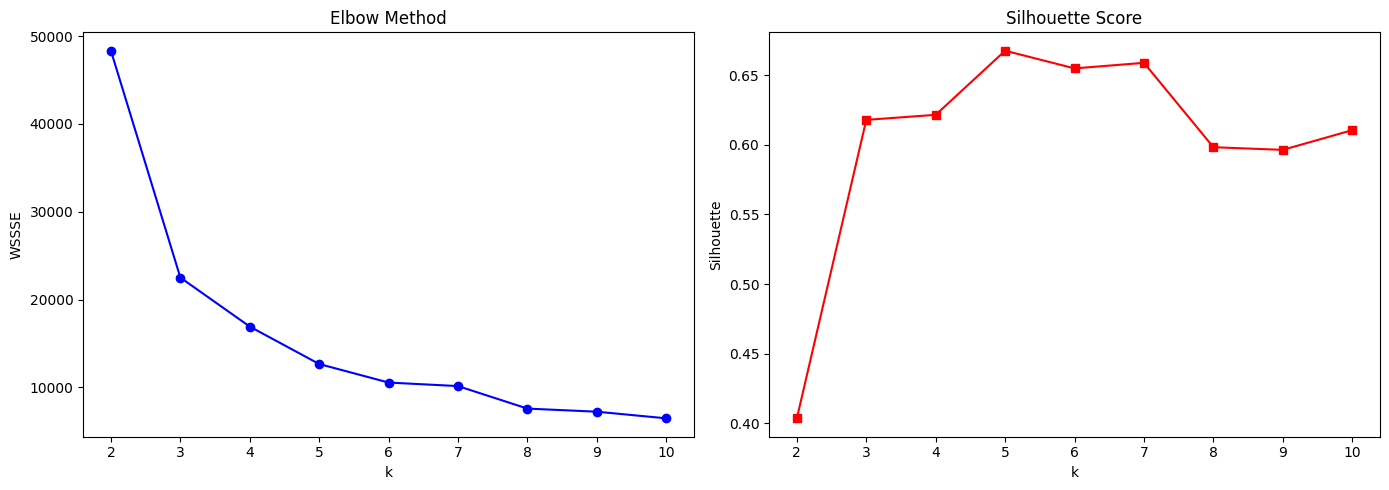

Optimal k (by silhouette): 5
+-------+------------+------------+------------+---------------+----------------+----------+
|cluster|Avg_NA_Ratio|Avg_EU_Ratio|Avg_JP_Ratio|Avg_Other_Ratio|Avg_Global_Sales|Game_Count|
+-------+------------+------------+------------+---------------+----------------+----------+
|0      |0.7997      |0.1164      |0.0248      |0.0424         |0.44            |6293      |
|1      |0.0222      |0.0111      |0.9568      |0.0085         |0.22            |3828      |
|2      |0.4681      |0.3732      |0.0441      |0.1162         |0.98            |5097      |
|3      |0.0438      |0.8448      |0.0081      |0.0771         |0.25            |1305      |
|4      |0.2526      |0.0823      |0.0413      |0.629          |1.19            |97        |
+-------+------------+------------+------------+---------------+----------------+----------+

Cluster labels: {0: 'NA-centric', 1: 'JP-centric', 2: 'NA-centric', 3: 'EU-centric', 4: 'Other-centric'}


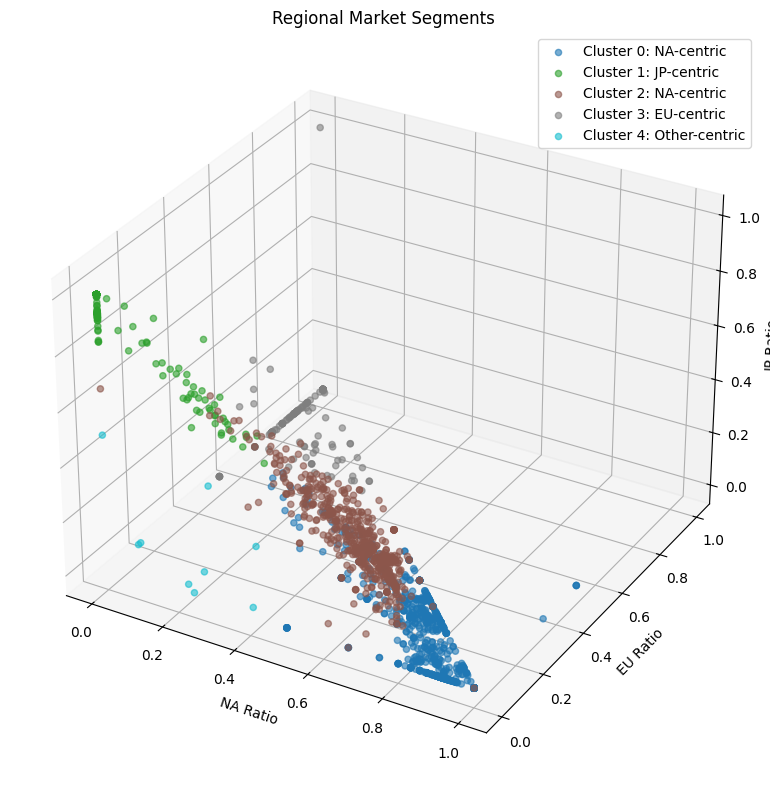

Cluster assignments exported for Tableau.


In [18]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import builtins

# Prepare data (use df_model)
df_cluster = df_model.withColumn("Other_Ratio",
    F.when(F.col("Global_Sales") > 0, F.round(F.col("Other_Sales") / F.col("Global_Sales"), 4)).otherwise(0))
ratio_cols = ["NA_Ratio", "EU_Ratio", "JP_Ratio", "Other_Ratio"]

# Assemble and scale
assembler_cl = VectorAssembler(inputCols=ratio_cols, outputCol="ratio_features")
df_cluster = assembler_cl.transform(df_cluster)
scaler_cl = StandardScaler(inputCol="ratio_features", outputCol="scaled_ratio_features", withStd=True, withMean=True)
df_cluster = scaler_cl.fit(df_cluster).transform(df_cluster).cache()

# Elbow method + Silhouette to find optimal k
costs, sil_scores = [], []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(featuresCol="scaled_ratio_features", predictionCol="cluster", k=k, seed=42)
    model = km.fit(df_cluster)
    costs.append(model.summary.trainingCost)
    preds = model.transform(df_cluster)
    eval = ClusteringEvaluator(featuresCol="scaled_ratio_features", predictionCol="cluster", metricName="silhouette")
    sil_scores.append(eval.evaluate(preds))
    print(f"k={k}  WSSSE={costs[-1]:.4f}  Silhouette={sil_scores[-1]:.4f}")

# Plot elbow and silhouette
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(k_range, costs, 'bo-'); ax1.set_xlabel('k'); ax1.set_ylabel('WSSSE'); ax1.set_title('Elbow Method')
ax2.plot(k_range, sil_scores, 'rs-'); ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette'); ax2.set_title('Silhouette Score')
plt.tight_layout(); plt.savefig('optimal_k.png', dpi=300); plt.show()

best_k = k_range[np.argmax(sil_scores)]
print(f"Optimal k (by silhouette): {best_k}")

# Fit final KMeans
kmeans_final = KMeans(featuresCol="scaled_ratio_features", predictionCol="cluster", k=best_k, seed=42)
model_final = kmeans_final.fit(df_cluster)
df_clustered = model_final.transform(df_cluster)

# Cluster profiles
cluster_profile = df_clustered.groupBy("cluster").agg(
    F.round(F.avg("NA_Ratio"),4).alias("Avg_NA_Ratio"),
    F.round(F.avg("EU_Ratio"),4).alias("Avg_EU_Ratio"),
    F.round(F.avg("JP_Ratio"),4).alias("Avg_JP_Ratio"),
    F.round(F.avg("Other_Ratio"),4).alias("Avg_Other_Ratio"),
    F.round(F.avg("Global_Sales"),2).alias("Avg_Global_Sales"),
    F.count("*").alias("Game_Count")
).orderBy("cluster")
cluster_profile.show(truncate=False)

# Label clusters
cluster_pd = cluster_profile.toPandas().set_index("cluster")
def label_cluster(row):
    regions = {'NA': row['Avg_NA_Ratio'], 'EU': row['Avg_EU_Ratio'], 'JP': row['Avg_JP_Ratio'], 'Other': row['Avg_Other_Ratio']}
    dominant = builtins.max(regions, key=regions.get)
    if builtins.max(regions.values()) - builtins.min(regions.values()) < 0.15:
        return "Balanced Global"
    else:
        return f"{dominant}-centric"

cluster_pd['Label'] = cluster_pd.apply(label_cluster, axis=1)
cluster_labels = cluster_pd['Label'].to_dict()
print("Cluster labels:", cluster_labels)

# Visualize clusters (3D scatter sample)
from mpl_toolkits.mplot3d import Axes3D
sample_n = builtins.min(2000, df_clustered.count())
sample_pd = df_clustered.select("NA_Ratio","EU_Ratio","JP_Ratio","cluster").sample(False, sample_n/df_clustered.count(), seed=42).toPandas()
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
colors = plt.cm.tab10(np.linspace(0,1,best_k))
for cl in range(best_k):
    cd = sample_pd[sample_pd['cluster']==cl]
    ax.scatter(cd['NA_Ratio'], cd['EU_Ratio'], cd['JP_Ratio'], c=[colors[cl]], label=f"Cluster {cl}: {cluster_labels[cl]}", s=20, alpha=0.6)
ax.set_xlabel('NA Ratio'); ax.set_ylabel('EU Ratio'); ax.set_zlabel('JP Ratio')
ax.legend(); plt.title('Regional Market Segments'); plt.tight_layout(); plt.savefig('cluster_3d.png', dpi=300); plt.show()

# Export clustered data for Tableau
df_clustered = df_clustered.withColumn("cluster_label",
    F.when(F.col("cluster")==0, cluster_labels[0])
     .when(F.col("cluster")==1, cluster_labels[1])
     .when(F.col("cluster")==2, cluster_labels[2])
     .when(F.col("cluster")==3, cluster_labels[3])
     .when(F.col("cluster")==4, cluster_labels[4])
     .otherwise("Other"))

export_cluster_cols = ["Name","Platform","Genre","Publisher","Year_of_Release",
                       "NA_Sales","EU_Sales","JP_Sales","Other_Sales","Global_Sales",
                       "NA_Ratio","EU_Ratio","JP_Ratio","Other_Ratio",
                       "cluster","cluster_label",
                       "Critic_Score","User_Score","Score_Divergence",
                       "Regional_Concentration","Platform_Age"]
avail_cl = [c for c in export_cluster_cols if c in df_clustered.columns]
df_clustered.select(*avail_cl).toPandas().to_csv("cluster_assignments_tableau.csv", index=False)
print("Cluster assignments exported for Tableau.")

Tableau File


In [19]:
import pandas as pd

# Load both exports
pred_df = pd.read_csv("video_game_predictions_tableau.csv")
clust_df = pd.read_csv("cluster_assignments_tableau.csv")

# Merge on Name (keep all cluster data, add predictions where available)
master_df = pd.merge(clust_df, pred_df[['Name', 'Predicted_Sales', 'Prediction_Error', 'Absolute_Error']],
                     on='Name', how='left')

# Save master file
master_df.to_csv("tableau_master.csv", index=False)
print(f"✓ tableau_master.csv created: {len(master_df)} rows, {len(master_df.columns)} columns")
print(f"Columns: {list(master_df.columns)}")

✓ tableau_master.csv created: 17888 rows, 24 columns
Columns: ['Name', 'Platform', 'Genre', 'Publisher', 'Year_of_Release', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'NA_Ratio', 'EU_Ratio', 'JP_Ratio', 'Other_Ratio', 'cluster', 'cluster_label', 'Critic_Score', 'User_Score', 'Score_Divergence', 'Regional_Concentration', 'Platform_Age', 'Predicted_Sales', 'Prediction_Error', 'Absolute_Error']
